# EpiLink usage notebook


## Setup


In [18]:
from __future__ import annotations

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

from epilink import EpiLink, InfectiousnessToTransmission, NaturalHistoryParameters

sns.set_theme(context='paper', style='white')
plt.rcParams.update(
    {
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
        'legend.fontsize': 8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'figure.titlesize': 13,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
    }
)

SEED = 2026
MAXIMUM_DEPTH = 10
DEFAULT_TARGET = ['ad(0)', 'ca(0,0)']
SCENARIOS = ['ad(0)', 'ca(0,0)', 'ad(1)', 'ca(0,1)', 'ca(1,0)', 'ca(1,1)']
SCENARIO_LABELS = {
    'ad(0)': 'AD(0)',
    'ca(0,0)': 'CA(0,0)',
    'ad(1)': 'AD(1)',
    'ca(0,1)': 'CA(0,1)',
    'ca(1,0)': 'CA(1,0)',
    'ca(1,1)': 'CA(1,1)',
}
WINNER_SCENARIOS = SCENARIOS.copy()
WINNER_LABELS = [SCENARIO_LABELS[label] for label in WINNER_SCENARIOS]
MUTATION_MODELS = {
    'Deterministic mutation draws': 'deterministic',
    'Stochastic mutation draws': 'stochastic',
}
SCENARIO_COLORS = {
    label: color for label, color in zip(SCENARIOS, sns.color_palette('deep', n_colors=len(SCENARIOS)), strict=True)
}


def make_model(
    *,
    mutation_process: str = 'stochastic',
    seed: int = SEED,
    substitution_rate: float | None = None,
    target: str | list[str] = 'ad(0)',
) -> EpiLink:
    parameters = NaturalHistoryParameters()
    if substitution_rate is not None:
        parameters = replace(parameters, substitution_rate=float(substitution_rate))
    profile = InfectiousnessToTransmission(parameters=parameters, rng_seed=seed)
    return EpiLink(
        transmission_profile=profile,
        maximum_depth=MAXIMUM_DEPTH,
        target=target,
        mutation_process=mutation_process,
    )


def compatibility_curve_from_draws(observed_values: np.ndarray, simulated_draws: np.ndarray) -> np.ndarray:
    sorted_draws = np.sort(np.asarray(simulated_draws, dtype=float))
    percentiles = np.searchsorted(sorted_draws, observed_values, side='right') / sorted_draws.size
    return 1.0 - 2.0 * np.abs(percentiles - 0.5)


def top_scenario_for_grid(
    model: EpiLink,
    time_grid: np.ndarray,
    genetic_grid: np.ndarray,
    scenario_labels: list[str],
) -> np.ndarray:
    winner_index = np.zeros((genetic_grid.size, time_grid.size), dtype=int)
    winner_score = np.full((genetic_grid.size, time_grid.size), -np.inf, dtype=float)
    for idx, label in enumerate(scenario_labels):
        score = model.score_target(time_grid[None, :], genetic_grid[:, None], target=label)
        update_mask = score > winner_score
        winner_index[update_mask] = idx
        winner_score[update_mask] = score[update_mask]
    return winner_index


def simulate_confusion(
    model: EpiLink,
    truth_labels: list[str],
    n_pairs: int = 150,
    seed: int = 11,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    confusion = np.zeros((len(truth_labels), len(truth_labels)), dtype=int)
    for i, truth in enumerate(truth_labels):
        draws = model.draws_by_scenario[truth]
        indices = rng.integers(0, len(draws['time_draws']), size=n_pairs)
        times = draws['time_draws'][indices]
        genetics = draws['genetic_draws'][indices]
        scores = np.stack(
            [np.asarray(model.score_target(times, genetics, target=label), dtype=float) for label in truth_labels],
            axis=0,
        )
        winners = np.argmax(scores, axis=0)
        for winner in winners:
            confusion[i, winner] += 1
    return confusion


def bootstrap_ci_mean(
    samples: np.ndarray,
    *,
    ci: float = 0.95,
    n_bootstrap: int = 400,
    seed: int = 0,
) -> tuple[float, float]:
    values = np.asarray(samples, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, values.size, size=(n_bootstrap, values.size))
    boot_means = values[indices].mean(axis=1)
    alpha = 1.0 - ci
    lower = float(np.quantile(boot_means, alpha / 2.0))
    upper = float(np.quantile(boot_means, 1.0 - alpha / 2.0))
    return lower, upper


def sensitivity_curve(
    substitution_rates: np.ndarray,
    mutation_process: str,
    truth_label: str = 'ad(0)',
    n_pairs: int = 120,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    base_model = make_model(
        mutation_process=mutation_process,
        seed=101,
        target='ad(0)',
    )
    base_draws = base_model.draws_by_scenario[truth_label]
    rng = np.random.default_rng(321)
    idx = rng.integers(0, len(base_draws['time_draws']), size=n_pairs)
    obs_time = base_draws['time_draws'][idx]
    obs_gen = base_draws['genetic_draws'][idx]

    accuracies = []
    accuracy_ci_low = []
    accuracy_ci_high = []
    mean_truth_scores = []
    score_ci_low = []
    score_ci_high = []

    truth_idx = WINNER_SCENARIOS.index(truth_label)
    for rate_idx, rate in enumerate(substitution_rates):
        model = make_model(
            mutation_process=mutation_process,
            seed=101,
            substitution_rate=float(rate),
            target='ad(0)',
        )
        scores = np.stack(
            [np.asarray(model.score_target(obs_time, obs_gen, target=label), dtype=float) for label in WINNER_SCENARIOS],
            axis=0,
        )
        winners = np.argmax(scores, axis=0)
        accuracy_samples = (winners == truth_idx).astype(float)
        truth_score_samples = scores[truth_idx]

        accuracies.append(float(np.mean(accuracy_samples)))
        mean_truth_scores.append(float(np.mean(truth_score_samples)))

        acc_low, acc_high = bootstrap_ci_mean(accuracy_samples, seed=1000 + rate_idx)
        score_low, score_high = bootstrap_ci_mean(truth_score_samples, seed=2000 + rate_idx)
        accuracy_ci_low.append(acc_low)
        accuracy_ci_high.append(acc_high)
        score_ci_low.append(score_low)
        score_ci_high.append(score_high)

    return (
        np.asarray(accuracies),
        np.asarray(accuracy_ci_low),
        np.asarray(accuracy_ci_high),
        np.asarray(mean_truth_scores),
        np.asarray(score_ci_low),
        np.asarray(score_ci_high),
    )


def finalize_axes(axes) -> None:
    flat_axes = np.atleast_1d(axes).ravel()
    for ax in flat_axes:
        ax.grid(False)
        sns.despine(ax=ax)


## 1. Quick start: score one observed pair

- What this shows: A minimal end-to-end example that initializes `EpiLink`, scores one observed pair, and ranks the most compatible scenarios.
- How to read it: Higher bars mean the observed pair is more compatible with that scenario. The printed target score is the sum over the chosen target subset.


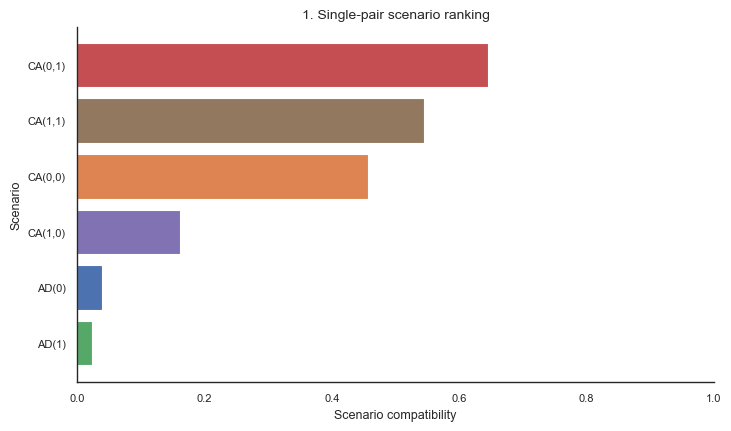

Observed time difference: 3.0 days
Observed genetic distance: 2.0 mutations
Target subset: ['ad(0)', 'ca(0,0)']
Summed target compatibility: 0.496


In [19]:
sample_time_difference = 3.0
genetic_distance = 2.0

model = make_model(
    mutation_process='stochastic',
    target=DEFAULT_TARGET,
)
result = model.score_pair(
    sample_time_difference=sample_time_difference,
    genetic_distance=genetic_distance,
)

compatibilities = np.array(
    [result['scenario_scores'][label]['compatibility'] for label in WINNER_SCENARIOS],
    dtype=float,
)
order = np.argsort(compatibilities)
ordered_labels = [SCENARIO_LABELS[WINNER_SCENARIOS[idx]] for idx in order]
ordered_values = compatibilities[order]
ordered_colors = [SCENARIO_COLORS[WINNER_SCENARIOS[idx]] for idx in order]

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.barh(ordered_labels, ordered_values, color=ordered_colors)
ax.set_xlabel('Scenario compatibility')
ax.set_ylabel('Scenario')
ax.set_xlim(0, 1.0)
ax.set_title('1. Single-pair scenario ranking')
finalize_axes(ax)
plt.show()

print(f'Observed time difference: {sample_time_difference:.1f} days')
print(f'Observed genetic distance: {genetic_distance:.1f} mutations')
print(f'Target subset: {result["target_labels"]}')
print(f'Summed target compatibility: {result["target_compatibility"]:.3f}')


In [32]:
pairwise = model.pairwise_model()

In [40]:
model.profile.expected_mutations(4).item()

0.5126487659214802

In [36]:
%%time
size = 100_000_000
compatibility = pairwise(
    sample_time_difference=np.arange(size),
    genetic_distance=np.arange(size),
)

print(f"Compatibility calculation for {size:,} pairs")

Compatibility calculation for 100,000,000 pairs
CPU times: user 1.06 s, sys: 2.58 s, total: 3.65 s
Wall time: 5.17 s


## 2. Default recent-transmission compatibility surface

- What this shows: The summed compatibility of `AD(0) + CA(0,0)` across a grid of observed testing-time differences and genetic distances.
- How to read it: Brighter regions indicate observations that look more compatible with recent transmission.
- What changes between panels: The stochastic panel includes Poisson mutation noise, so support can broaden or shift relative to the deterministic panel.


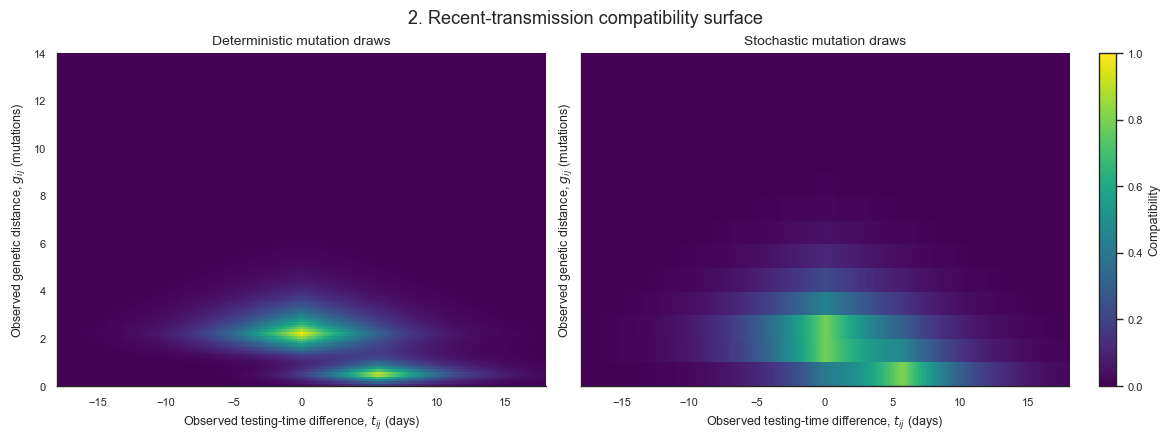

In [3]:
t_grid = np.linspace(-18, 18, 181)
g_grid = np.linspace(0, 14, 141)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    model = make_model(
        mutation_process=mutation_process,
        target=DEFAULT_TARGET,
    )
    compatibility = model.score_target(t_grid[None, :], g_grid[:, None], target=DEFAULT_TARGET)
    last_image = ax.imshow(
        compatibility,
        origin='lower',
        aspect='auto',
        extent=(float(t_grid.min()), float(t_grid.max()), float(g_grid.min()), float(g_grid.max())),
        interpolation='nearest',
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
    ax.set_ylabel(r'Observed genetic distance, $g_{ij}$ (mutations)')

colorbar = fig.colorbar(last_image, ax=axes, fraction=0.046, pad=0.03, label='Compatibility')
colorbar.set_ticks(np.linspace(0, 1, 6))
fig.suptitle('2. Recent-transmission compatibility surface')
finalize_axes(axes)
plt.show()


## 3. Temporal compatibility profiles

- What this shows: Compatibility as a function of observed testing-time difference for the main recent scenarios.
- How to read it: Each curve peaks where that scenario expects the relative timing of tests to fall. The closer the curve is to 1, the more temporally plausible the observation is.
- Why there is only one panel: Temporal compatibility does not depend on deterministic versus stochastic mutation draws.


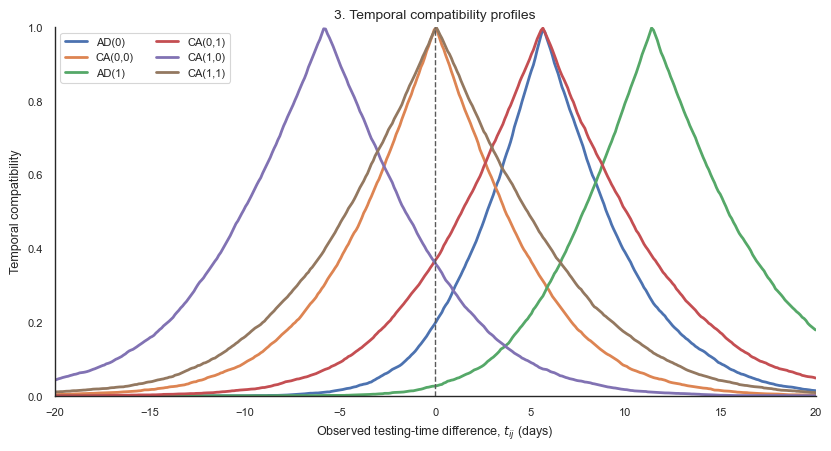

In [16]:
model = make_model(mutation_process='stochastic', target='ad(0)')
time_axis = np.linspace(-20, 20, 400)

fig, ax = plt.subplots(figsize=(8.2, 4.4), constrained_layout=True)
for label in SCENARIOS:
    curve = compatibility_curve_from_draws(time_axis, model.draws_by_scenario[label]['time_draws'])
    ax.plot(
        time_axis,
        curve,
        linewidth=2,
        color=SCENARIO_COLORS[label],
        label=SCENARIO_LABELS[label],
    )

ax.axvline(0, linewidth=1, color='0.35', linestyle='--')
ax.set_xlim(time_axis.min(), time_axis.max())
ax.set_ylim(0, 1.0)
ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
ax.set_ylabel('Temporal compatibility')
ax.set_title('3. Temporal compatibility profiles')
ax.legend(ncol=2, loc='best')
finalize_axes(ax)
plt.show()

## 4. Genetic compatibility profiles

- What this shows: Compatibility as a function of observed genetic distance for the same scenarios used above.
- How to read it: Curves closer to 1 indicate mutation distances that are more plausible under a given scenario.
- What changes between panels: Deterministic draws use expected mutation counts, while stochastic draws add count noise through Poisson sampling.


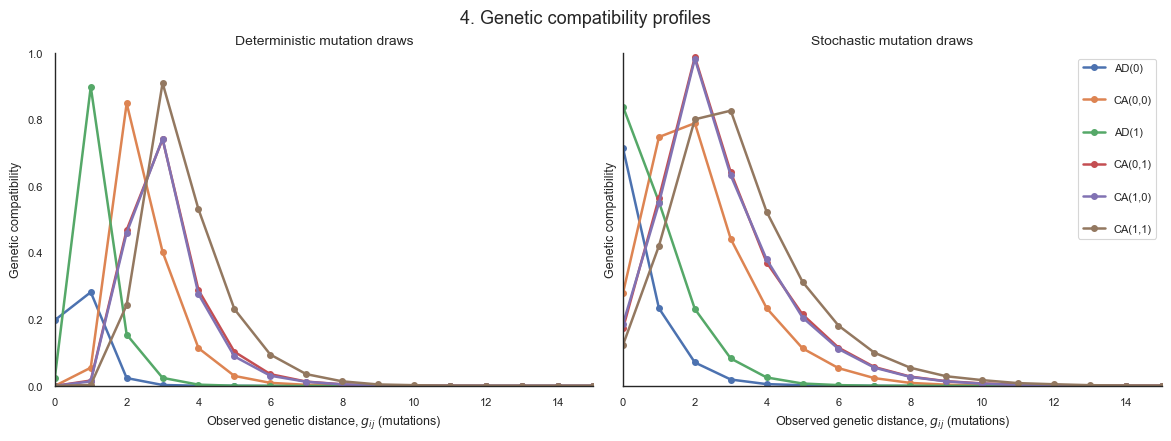

In [20]:
genetic_axis = np.arange(0, 16)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), sharex=True, sharey=True, constrained_layout=True)
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    model = make_model(mutation_process=mutation_process, target='ad(0)')
    for label in SCENARIOS:
        curve = compatibility_curve_from_draws(genetic_axis, model.draws_by_scenario[label]['genetic_draws'])
        ax.plot(
            genetic_axis,
            curve,
            marker='o',
            markersize=4,
            linewidth=1.8,
            color=SCENARIO_COLORS[label],
            label=SCENARIO_LABELS[label],
        )
    ax.set_title(title)
    ax.set_xlabel(r'Observed genetic distance, $g_{ij}$ (mutations)')
    ax.set_ylabel('Genetic compatibility')
    ax.set_xlim(genetic_axis.min(), genetic_axis.max())
    ax.set_ylim(0, 1.0)

axes[1].legend(loc='best', labelspacing=2)
fig.suptitle('4. Genetic compatibility profiles')
finalize_axes(axes)
plt.show()


## 5. Highest-compatibility scenario map

- What this shows: For each observed combination of timing and genetic distance, the plot records which latent scenario has the highest compatibility.
- How to read it: Each color marks the locally winning scenario. Sharp boundaries indicate where the preferred explanation changes.
- What changes between panels: Mutation noise can move the boundaries between competing scenarios.


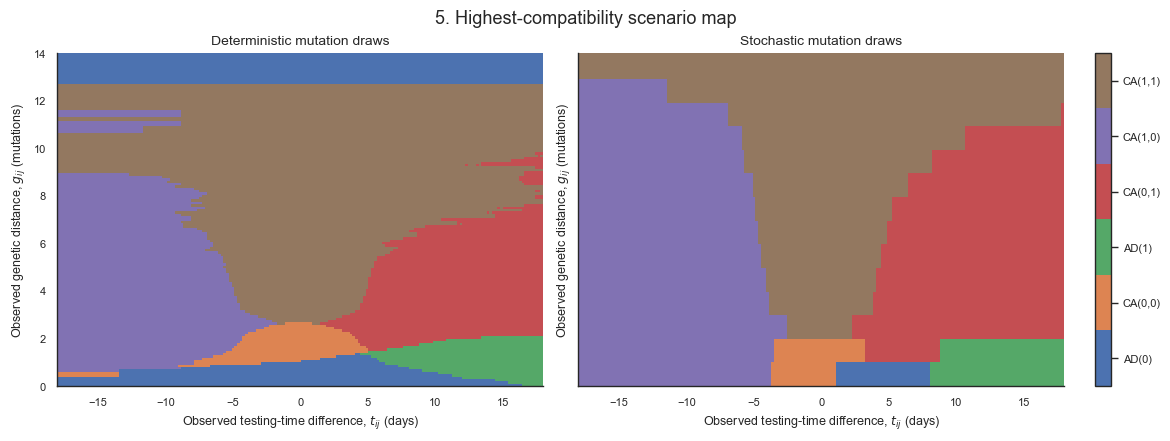

In [6]:
t_grid = np.linspace(-18, 18, 181)
g_grid = np.linspace(0, 14, 141)
cmap = ListedColormap([SCENARIO_COLORS[label] for label in WINNER_SCENARIOS])

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    model = make_model(mutation_process=mutation_process, target='ad(0)')
    winner_index = top_scenario_for_grid(model, t_grid, g_grid, WINNER_SCENARIOS)
    last_image = ax.imshow(
        winner_index,
        origin='lower',
        aspect='auto',
        extent=(float(t_grid.min()), float(t_grid.max()), float(g_grid.min()), float(g_grid.max())),
        cmap=cmap,
        interpolation='nearest',
        vmin=-0.5,
        vmax=len(WINNER_SCENARIOS) - 0.5,
    )
    ax.set_title(title)
    ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
    ax.set_ylabel(r'Observed genetic distance, $g_{ij}$ (mutations)')

colorbar = fig.colorbar(last_image, ax=axes, ticks=np.arange(len(WINNER_SCENARIOS)), fraction=0.046, pad=0.03)
colorbar.ax.set_yticklabels(WINNER_LABELS)
fig.suptitle('5. Highest-compatibility scenario map')
finalize_axes(axes)
plt.show()


## 6. Scenario recovery from simulated pairs

- What this shows: A confusion matrix summarizing how often the top-ranked inferred scenario matches the true simulated scenario.
- How to read it: Strong diagonal values indicate good recovery. Off-diagonal mass highlights scenarios that are hard to separate.
- What changes between panels: Stochastic mutation draws typically make misclassification more visible because mutation counts vary around their expectations.


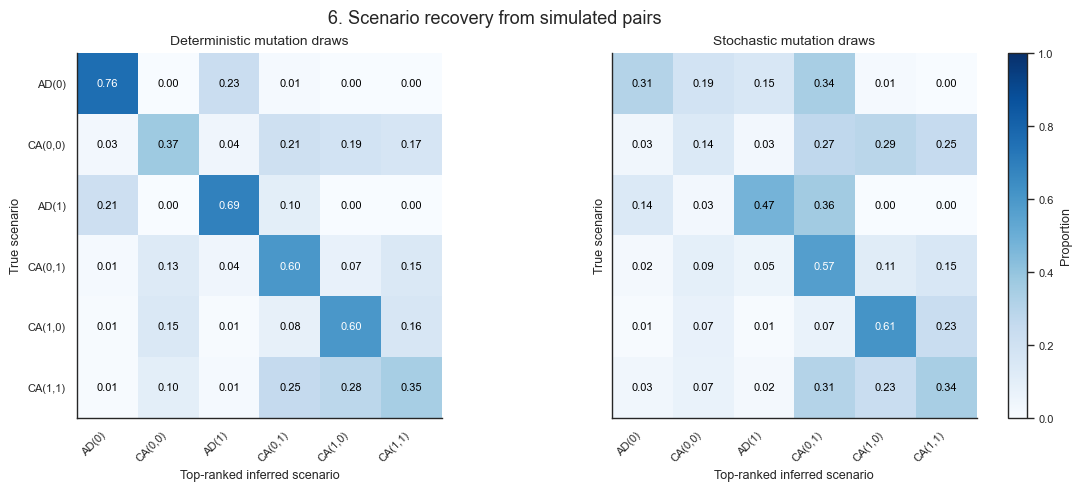

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.8), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    model = make_model(mutation_process=mutation_process, target='ad(0)')
    confusion = simulate_confusion(model, WINNER_SCENARIOS, n_pairs=150)
    confusion_prop = confusion / confusion.sum(axis=1, keepdims=True)
    last_image = ax.imshow(confusion_prop, vmin=0, vmax=1, aspect='equal', cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(np.arange(len(WINNER_LABELS)))
    ax.set_xticklabels(WINNER_LABELS, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(WINNER_LABELS)))
    ax.set_yticklabels(WINNER_LABELS)
    ax.set_xlabel('Top-ranked inferred scenario')
    ax.set_ylabel('True scenario')
    for i in range(confusion_prop.shape[0]):
        for j in range(confusion_prop.shape[1]):
            value = confusion_prop[i, j]
            text_color = 'white' if value > 0.55 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=8, color=text_color)

fig.colorbar(last_image, ax=axes, fraction=0.046, pad=0.03, label='Proportion')
fig.suptitle('6. Scenario recovery from simulated pairs')
finalize_axes(axes)
plt.show()


## 7. Sensitivity to the assumed mutation rate

- What this shows: The effect of changing the substitution-rate assumption on both top-1 scenario recovery and the average compatibility assigned to the true scenario.
- How to read it: Stable curves suggest robustness to the mutation-rate assumption. Wider confidence bands indicate more uncertainty in the estimated summary.
- What changes between panels: Deterministic and stochastic mutation models can respond differently to rate misspecification because one uses expected counts and the other uses sampled counts.


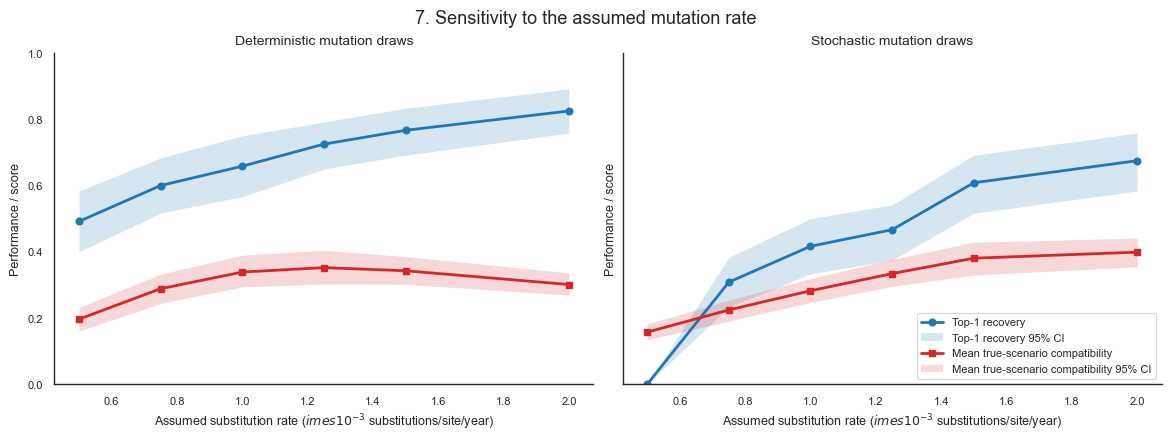

In [8]:
substitution_rates = np.array([0.5e-3, 0.75e-3, 1.0e-3, 1.25e-3, 1.5e-3, 2.0e-3])

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), sharex=True, sharey=True, constrained_layout=True)
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    (
        sensitivity_accuracy,
        sensitivity_accuracy_low,
        sensitivity_accuracy_high,
        sensitivity_truth_score,
        sensitivity_truth_score_low,
        sensitivity_truth_score_high,
    ) = sensitivity_curve(substitution_rates, mutation_process=mutation_process)

    x_values = substitution_rates * 1e3
    ax.plot(x_values, sensitivity_accuracy, marker='o', linewidth=2, color='#1f77b4', label='Top-1 recovery')
    ax.fill_between(
        x_values,
        sensitivity_accuracy_low,
        sensitivity_accuracy_high,
        color='#1f77b4',
        alpha=0.18,
        linewidth=0,
        label='Top-1 recovery 95% CI',
    )
    ax.plot(x_values, sensitivity_truth_score, marker='s', linewidth=2, color='#d62728', label='Mean true-scenario compatibility')
    ax.fill_between(
        x_values,
        sensitivity_truth_score_low,
        sensitivity_truth_score_high,
        color='#d62728',
        alpha=0.18,
        linewidth=0,
        label='Mean true-scenario compatibility 95% CI',
    )
    ax.set_title(title)
    ax.set_xlabel(r'Assumed substitution rate ($	imes 10^{-3}$ substitutions/site/year)')
    ax.set_ylabel('Performance / score')
    ax.set_ylim(0, 1.0)

axes[1].legend(loc='lower right')
fig.suptitle('7. Sensitivity to the assumed mutation rate')
finalize_axes(axes)
plt.show()
